MULTI-SERVER CONFIDENCE INTERVAL ESTIMATION
---------------------------------------------
Number of Servers:      2
Number of Replications: 100
Sample Mean:            0.2265
Sample Std Deviation:   0.1552
95% Confidence Interval: (0.1957, 0.2572)


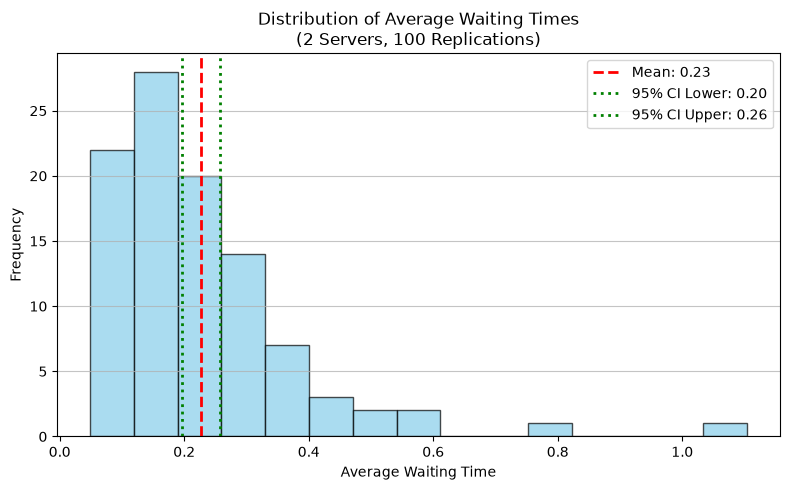

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def simulate_mmc_queue(num_customers: int, num_servers: int, mean_interarrival: float, mean_service: float) -> float:
    """
    Simulates a multi-server (M/M/c) queue and returns the average waiting time.
    """
    arrival_time = 0.0
    
    # Track the time each server becomes free
    server_free_times = [0.0] * num_servers
    total_wait = 0.0

    # Pre-generate random distributions
    interarrivals = np.random.exponential(mean_interarrival, num_customers)
    service_times = np.random.exponential(mean_service, num_customers)

    for i in range(num_customers):
        arrival_time += interarrivals[i]
        
        # Find the server that becomes free earliest
        earliest_free_time = min(server_free_times)
        earliest_server_idx = server_free_times.index(earliest_free_time)
        
        wait_time = max(0.0, earliest_free_time - arrival_time)
        total_wait += wait_time
        
        service_start = max(arrival_time, earliest_free_time)
        
        # Update the chosen server's free time
        server_free_times[earliest_server_idx] = service_start + service_times[i]

    return total_wait / num_customers

def main():
    # -----------------------------------
    # Simulation Parameters
    # -----------------------------------
    NUM_REPLICATIONS = 100 # Increased for a better histogram visualization
    NUM_CUSTOMERS = 100
    NUM_SERVERS = 2        # New parameter: Number of servers handling customers
    MEAN_INTERARRIVAL = 2.0
    MEAN_SERVICE = 1.5

    # -----------------------------------
    # Run Independent Replications
    # -----------------------------------
    average_waiting_times = [
        simulate_mmc_queue(NUM_CUSTOMERS, NUM_SERVERS, MEAN_INTERARRIVAL, MEAN_SERVICE) 
        for _ in range(NUM_REPLICATIONS)
    ]Lab 16: Steady-State Analysis: Analyze the warm-up period of a non-terminating simulation (like a continuous manufacturing line) and calculate the steady-state mean time.

    # -----------------------------------
    # Confidence Interval Calculation
    # -----------------------------------
    sample_mean = np.mean(average_waiting_times)
    sample_std = np.std(average_waiting_times, ddof=1)
    
    t_value = stats.t.ppf(0.975, df=NUM_REPLICATIONS - 1)
    margin_error = t_value * (sample_std / np.sqrt(NUM_REPLICATIONS))
    
    lower = sample_mean - margin_error
    upper = sample_mean + margin_error

    # -----------------------------------
    # Print Results
    # -----------------------------------
    print("MULTI-SERVER CONFIDENCE INTERVAL ESTIMATION")
    print("-" * 45)
    print(f"Number of Servers:      {NUM_SERVERS}")
    print(f"Number of Replications: {NUM_REPLICATIONS}")
    print(f"Sample Mean:            {sample_mean:.4f}")
    print(f"Sample Std Deviation:   {sample_std:.4f}")
    print(f"95% Confidence Interval: ({lower:.4f}, {upper:.4f})")

    # -----------------------------------
    # Data Visualization
    # -----------------------------------
    plt.figure(figsize=(8, 5))
    plt.hist(average_waiting_times, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Add vertical lines for mean and confidence interval
    plt.axvline(sample_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {sample_mean:.2f}')
    plt.axvline(lower, color='green', linestyle='dotted', linewidth=2, label=f'95% CI Lower: {lower:.2f}')
    plt.axvline(upper, color='green', linestyle='dotted', linewidth=2, label=f'95% CI Upper: {upper:.2f}')
    
    plt.title(f"Distribution of Average Waiting Times\n({NUM_SERVERS} Servers, {NUM_REPLICATIONS} Replications)")
    plt.xlabel("Average Waiting Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()